# Inferencia Bayesiana Simulada: ejemplo de una moneda con `sbi`

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/teorico_practicos/Semana06_sbi_01.ipynb)

En esta notebook vamos a usar un ejemplo muy simple para entender la lógica de la **inferencia bayesiana basada en simulaciones** o **simulation-based inference (SBI)**.

## Parte 1

### Inferencia bayesiana clásica con lanzamientos de moneda

Supongamos que no conocemos la probabilidad de obtener cara al lanzar una moneda. Llamaremos $p$ a esa probabilidad y asumiremos, antes de observar datos, que cualquier valor en el intervalo $(0,1)$ es razonable.

Luego comenzamos a lanzar la moneda y registramos observaciones del tipo $H$ (cara) o $T$ (ceca). La pregunta central es cómo cambia nuestra inferencia sobre $p$ cuando tenemos pocos datos y cómo se concentra la posterior cuando acumulamos muchos lanzamientos.

En la siguiente celda se muestra esa actualización progresiva de la distribución posterior a medida que observamos más datos.

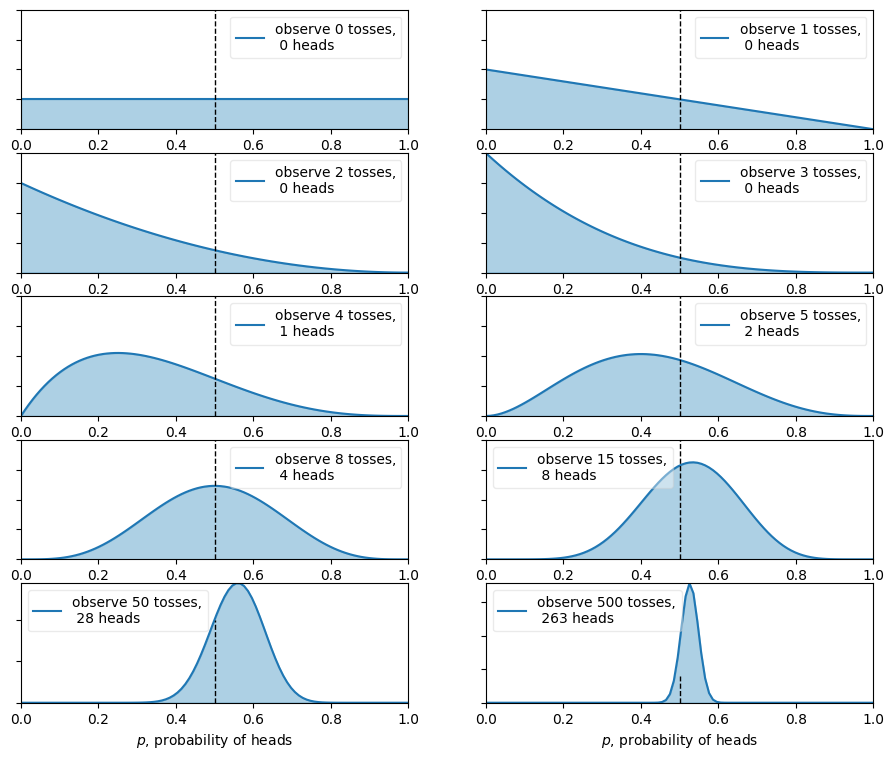

In [1]:
%matplotlib inline
from IPython.core.pylabtools import figsize
import numpy as np
from matplotlib import pyplot as plt
figsize(11, 9)

import scipy.stats as stats

dist = stats.beta
n_trials = [0, 1, 2, 3, 4, 5, 8, 15, 50, 500]
data = stats.bernoulli.rvs(0.5, size=n_trials[-1])
x = np.linspace(0, 1, 100)

# Usamos la prior conjugada Beta-Binomial para actualizar la posterior.
for k, N in enumerate(n_trials):
    sx = plt.subplot(int(len(n_trials) / 2), 2, k + 1)
    plt.xlabel("$p$, probabilidad de cara") 
    #if k in [0, len(n_trials) - 1] else None
    plt.setp(sx.get_yticklabels(), visible=False)
    heads = data[:N].sum()
    y = dist.pdf(x, 1 + heads, 1 + N - heads)  # La Beta muestra cómo la prior modifica la posterior.
    plt.plot(x, y, label="observo %d lanzamientos,\n %d caras" % (N, heads))
    plt.fill_between(x, 0, y, color="#348ABD", alpha=0.4)
    plt.vlines(0.5, 0, 4, color="k", linestyles="--", lw=1)

    leg = plt.legend()
    leg.get_frame().set_alpha(0.4)
    plt.autoscale(tight=True)

## Parte 2

### Llevar el mismo problema al marco de SBI

En este ejemplo la posterior exacta se puede escribir de forma analítica, así que no hace falta usar métodos de muestreo ni SBI para resolverlo. Sin embargo, justamente por ser un caso simple, sirve muy bien para entender cómo se formula el mismo problema dentro del paquete `sbi`.

Para eso definimos un simulador con un único parámetro $p$ que genera ensayos de Bernoulli. Fijamos además el número de lanzamientos en $N=50$ y elegimos una prior uniforme sobre el intervalo $(0,1)$.

In [2]:
import torch
from sbi import utils as utils
from sbi import analysis as analysis
from sbi.inference import infer

N=50
def simulator(p):    
    return torch.tensor(stats.bernoulli.rvs(p, size=N))
    
prior=utils.BoxUniform(low=torch.tensor([0.01]),high=torch.tensor([0.99]))    


/Users/robledo/.virtualenvs/sbi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Con el simulador y la prior definidos, ahora generamos simulaciones y entrenamos una aproximación de la posterior. Vamos a usar **SNPE** (*Sequential Neural Posterior Estimation*), que aprende la distribución posterior completa a partir de simulaciones usando un *normalizing flow*.

La ventaja de este enfoque es que, una vez entrenado el modelo, podemos muestrear de la posterior directamente sin ejecutar un algoritmo adicional de MCMC.

In [3]:
posterior = infer(simulator, prior, method="SNPE", num_simulations=10000)

100%|██████████| 10000/10000 [00:00<00:00, 38540.71it/s]
/Users/robledo/repos/sbi/sbi/neural_nets/net_builders/flow.py:141: UserWarning: In one-dimensional output space, this flow is limited to Gaussians
  x_numel = get_numel(


 Neural network successfully converged after 35 epochs.

## Parte 3

### Inferir $p$ a partir de una observación concreta

Ahora pasamos al modelo una observación concreta con el objetivo de inferir el parámetro $p$. Usamos los mismos datos del enfoque bayesiano clásico para poder comparar ambos resultados. Notar que, si cambiamos el valor de $N$, hay que volver a ejecutar la inferencia porque cambia la dimensión de la observación simulada.

Después extraemos muestras de la posterior aprendida para visualizar la distribución inferida sobre $p$.

Si querés experimentar, podés reemplazar `SNPE` por `SNRE` o `SNLE` y comparar cómo cambian los resultados. En esos casos, el muestreo posterior suele ser más costoso porque requiere ejecutar un algoritmo de MCMC.

In [4]:
observation=data[:N]
samples = posterior.sample((10000,), x=observation)


Drawing 10000 posterior samples for 1 observations: 100%|██████████| 10000/10000 [00:00<00:00, 567541.78it/s]


## Comentarios finales

En la última figura graficamos la distribución posterior estimada junto con el valor verdadero del parámetro, que en este ejemplo es $p=0.5$. La forma general de la distribución debería parecerse bastante a la obtenida con la inferencia bayesiana clásica.

La diferencia principal es que ahora trabajamos con una posterior **aproximada** aprendida por una red neuronal. Aunque en este problema eso no es necesario, el ejemplo deja claro el flujo de trabajo de SBI para casos donde la posterior exacta ya no se puede escribir analíticamente.

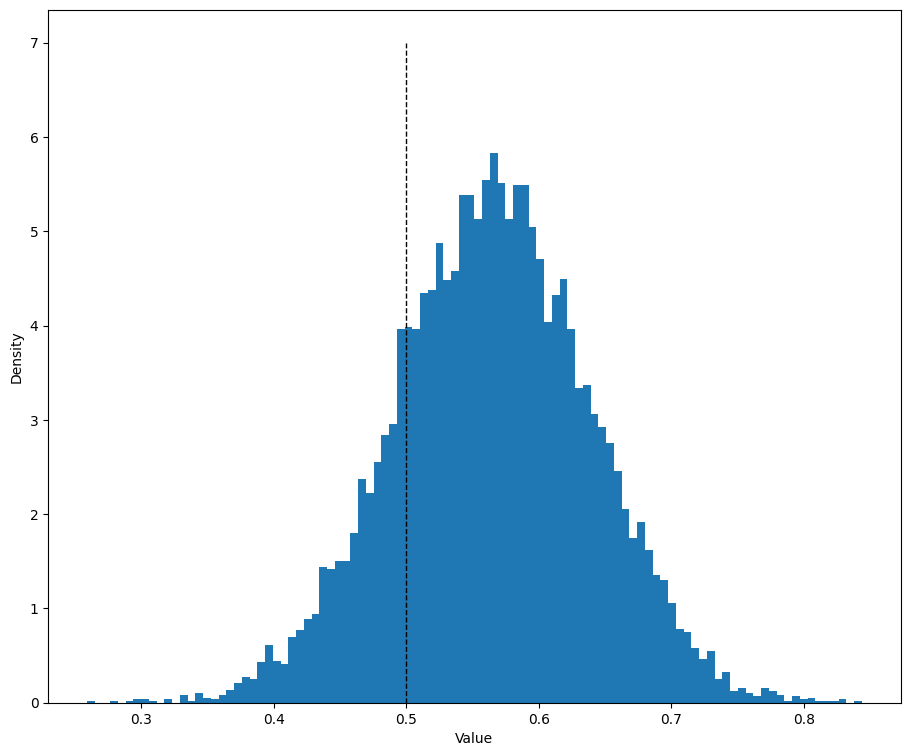

In [5]:
plt.hist(samples.numpy(), bins=100, density=True)
plt.vlines(0.5, 0, 7, color="k", linestyles="--", lw=1)
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.show()